<h1> Ligase Ablation Analysis</h1>


In [1]:
from pathlib import Path
from typing import Final

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
ROOT: Final[Path] = Path.cwd() if (Path.cwd() / "benchmarks").exists() else Path.cwd().parent
BENCH: Final[Path] = ROOT / "benchmarks"

LABEL: Final[dict[str, str]] = {
    "esm2_t33_650M": "ESM-2 650M",
    "ankh_base": "Ankh base",
}

In [3]:
FILES: Final[dict[tuple[str, str], str]] = {
    ("esm2_t33_650M", "legacy"): "ablation_esm.csv",
    ("esm2_t33_650M", "groups"): "ablation_esm_cb513_groups.csv",
    ("ankh_base", "legacy"): "ablation_ankh.csv",
    ("ankh_base", "groups"): "ablation_ankh_cb513_groups.csv",
}

In [4]:
# check for missing files
missing: list[str] = [name for name in FILES.values() if not (BENCH / name).exists()]
assert not missing, f"missing CSVs (run the grids first): {missing}"

In [5]:
# load all dataframes
frames: list[pd.DataFrame] = []

for (embed, split), name in FILES.items():
    df: pd.DataFrame = pd.read_csv(BENCH / name)
    df["embed"] = embed
    df["split"] = split
    frames.append(df)

abl: pd.DataFrame = pd.concat(frames, ignore_index=True)

In [6]:
# one test set per regime so we don't accidentally mix runs
n_test_counts = abl.groupby(["embed", "split"])["n_test"].nunique()
assert bool((n_test_counts == 1).all())

abl = abl.sort_values(["embed", "split", "features", "model", "mode"]).reset_index(drop=True)

print(f"loaded {len(abl)} rows across {len(FILES)} regimes from {BENCH}")

loaded 26 rows across 4 regimes from /mnt/c/Users/andre/Documents/ligase/benchmarks


<h3>Q3 accuracy on held-out test structures</h3>

Rows that were not executed appear as NaN (the Ankh replication subset for instance)

In [7]:
piv: pd.DataFrame = abl.pivot_table(
    index=["features", "model", "mode"],
    columns=["embed", "split"],
    values="Q3_accuracy",
)
piv.round(4)

embed                    ankh_base         esm2_t33_650M        
split                       groups  legacy        groups  legacy
features model   mode                                           
both     gearnet concat        NaN     NaN        0.7589  0.7888
                 project       NaN     NaN        0.8132  0.8189
         gvp     concat        NaN     NaN        0.4287  0.5018
         mlp     concat     0.8406  0.8518        0.8386  0.8514
seq      gearnet concat        NaN     NaN        0.8064  0.8255
         gvp     concat        NaN     NaN        0.4242  0.4090
         mlp     concat     0.8416  0.8515        0.8384  0.8462
struct   gearnet concat     0.6879  0.7077        0.6879  0.7077
         gvp     concat        NaN     NaN        0.5601  0.4379
         mlp     concat        NaN     NaN        0.3574  0.3514

<h4>Findings</h4>

In [8]:
def q3(
    embed: str,
    split: str,
    features: str,
    model: str,
    mode: str = "concat",
) -> float:
    sel: pd.DataFrame = abl[
        (abl["embed"] == embed)
        & (abl["split"] == split)
        & (abl["features"] == features)
        & (abl["model"] == model)
        & (abl["mode"] == mode)
    ]

    assert len(sel) == 1, (embed, split, features, model, mode)

    value = sel["Q3_accuracy"].iloc[0]
    assert pd.notna(value), (embed, split, features, model, mode)

    return float(value)


lines: list[str] = []

for embed in LABEL:
    for split in ("legacy", "groups"):
        gain: float = q3(embed, split, "both", "mlp") - q3(embed, split, "seq", "mlp")

        lines.append(
            f"- **{LABEL[embed]} / {split}**: graft gain (both/mlp − seq/mlp) = {gain:+.4f}"
        )

    struct_rows: pd.DataFrame = abl[(abl["embed"] == embed) & (abl["features"] == "struct")]

    best_value = struct_rows["Q3_accuracy"].max()
    assert pd.notna(best_value)

    best: float = float(best_value)
    base: float = q3(embed, "legacy", "seq", "mlp")

    lines.append(
        f"- **{LABEL[embed]}**: best structure-only row {best:.4f} "
        f"vs seq/mlp baseline {base:.4f} -> gap {base - best:+.4f} "
        f"(structure loses)"
    )

print("\n".join(lines))

- **ESM-2 650M / legacy**: graft gain (both/mlp − seq/mlp) = +0.0052
- **ESM-2 650M / groups**: graft gain (both/mlp − seq/mlp) = +0.0002
- **ESM-2 650M**: best structure-only row 0.7077 vs seq/mlp baseline 0.8462 -> gap +0.1385 (structure loses)
- **Ankh base / legacy**: graft gain (both/mlp − seq/mlp) = +0.0003
- **Ankh base / groups**: graft gain (both/mlp − seq/mlp) = -0.0010
- **Ankh base**: best structure-only row 0.7077 vs seq/mlp baseline 0.8515 -> gap +0.1438 (structure loses)


Read: the pLDDT graft's apparent gain under the random split shrinks to ~0 under group protection 
No structure-based row reaches the sequence baseline in any of the four regimes. 

Conclusion on CB513-class Q3 with frozen PLMs: **structure does not beat the PLM**

<h3>
Leakage measurement:  D =  group split − legacy split
</h3>

 The test sets differ across regimes (75 vs 76 *different* proteins), so d is indicative, rather than a paired test. For the strong (mlp/gearnet) rows it doubles as an empirical noise floor: split-to-split variation on rows is ~0.01–0.03. The GVP swings are that model's variance (because I use one hyperparameter set for all rows), not leakage.

In [9]:
def delta_table(embed: str) -> pd.DataFrame:
    leg: pd.DataFrame = abl[(abl["embed"] == embed) & (abl["split"] == "legacy")]

    grp: pd.DataFrame = abl[(abl["embed"] == embed) & (abl["split"] == "groups")]

    key: list[str] = ["features", "model", "mode"]

    out: pd.DataFrame = leg.set_index(key)[["Q3_accuracy", "f1_macro"]].join(
        grp.set_index(key)[["Q3_accuracy", "f1_macro"]],
        lsuffix="_legacy",
        rsuffix="_groups",
        how="inner",
    )

    out["delta_Q3"] = out["Q3_accuracy_groups"] - out["Q3_accuracy_legacy"]

    return out.sort_values("delta_Q3").round(4)

In [10]:
delta_table("esm2_t33_650M")

Q3_accuracy_legacy  f1_macro_legacy  \
features model   mode                                           
both     gvp     concat               0.5018           0.4466   
         gearnet concat               0.7888           0.7894   
struct   gearnet concat               0.7077           0.6949   
seq      gearnet concat               0.8255           0.8264   
both     mlp     concat               0.8514           0.8523   
seq      mlp     concat               0.8462           0.8458   
both     gearnet project              0.8189           0.8160   
struct   mlp     concat               0.3514           0.1734   
seq      gvp     concat               0.4090           0.3220   
struct   gvp     concat               0.4379           0.3345   

                          Q3_accuracy_groups  f1_macro_groups  delta_Q3  
features model   mode                                                    
both     gvp     concat               0.4287           0.4092   -0.0731  
         gearnet concat               0.7589           0.7565   -0.0300  
struct   gearnet concat               0.6879           0.6803   -0.0198  
seq      gearnet concat               0.8064           0.8047   -0.0191  
both     mlp     concat               0.8386           0.8381   -0.0128  
seq      mlp     concat               0.8384           0.8371   -0.0078  
both     gearnet project              0.8132           0.8109   -0.0057  
struct   mlp     concat               0.3574           0.1755    0.0059  
seq      gvp     concat               0.4242           0.3959    0.0153  
struct   gvp     concat               0.5601           0.5549    0.1222

In [11]:
delta_table("ankh_base")

,,,Q3_accuracy_legacy,f1_macro_legacy,Q3_accuracy_groups,f1_macro_groups,delta_Q3
features,model,mode,,,,,
struct,gearnet,concat,0.7077,0.6949,0.6879,0.6803,-0.0198
both,mlp,concat,0.8518,0.8520,0.8406,0.8406,-0.0112
seq,mlp,concat,0.8515,0.8517,0.8416,0.8406,-0.0099


<h3>ESM2 grid plotted</h3>

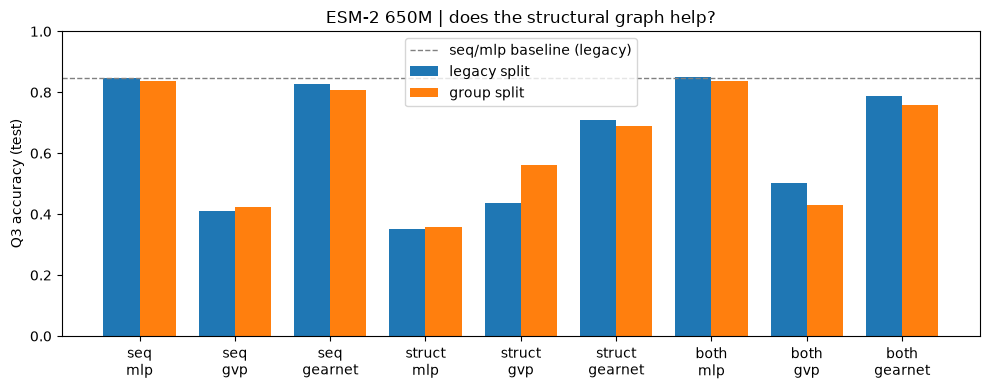

In [12]:
order: list[tuple[str, str]] = [
    (features, model)
    for features in ("seq", "struct", "both")
    for model in ("mlp", "gvp", "gearnet")
]

esm_leg: pd.DataFrame = abl[
    (abl["embed"] == "esm2_t33_650M") & (abl["split"] == "legacy") & (abl["mode"] == "concat")
]

esm_grp: pd.DataFrame = abl[
    (abl["embed"] == "esm2_t33_650M") & (abl["split"] == "groups") & (abl["mode"] == "concat")
]

leg_s = esm_leg.set_index(["features", "model"])["Q3_accuracy"]
grp_s = esm_grp.set_index(["features", "model"])["Q3_accuracy"]

x: np.ndarray = np.arange(len(order))
w: float = 0.38

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    x - w / 2,
    [float(leg_s.loc[p]) for p in order],
    w,
    label="legacy split",
)

ax.bar(
    x + w / 2,
    [float(grp_s.loc[p]) for p in order],
    w,
    label="group split",
)

ax.axhline(
    float(leg_s.loc[("seq", "mlp")]),
    ls="--",
    c="gray",
    lw=1,
    label="seq/mlp baseline (legacy)",
)

ax.set_xticks(x, [f"{features}\n{model}" for features, model in order])
ax.set_ylim(0, 1)
ax.set_ylabel("Q3 accuracy (test)")
ax.set_title("ESM-2 650M | does the structural graph help?")
ax.legend()

fig.tight_layout()

The structure-blind MLP (with or without pLDDT) tops the table (acounting for complexity); feeding the same embeddings through the graph pathway (both/gearnet) *hurts*. The graph does actually help struct/gearnet is respectable from geometry alone (on a small 3 layers model nonetheless), and recovers strand signal (E-F1) that the confidence-only baseline cannot (although ESM-2 already carries said signal).

<h3> Comparison accross PLMs </h3>

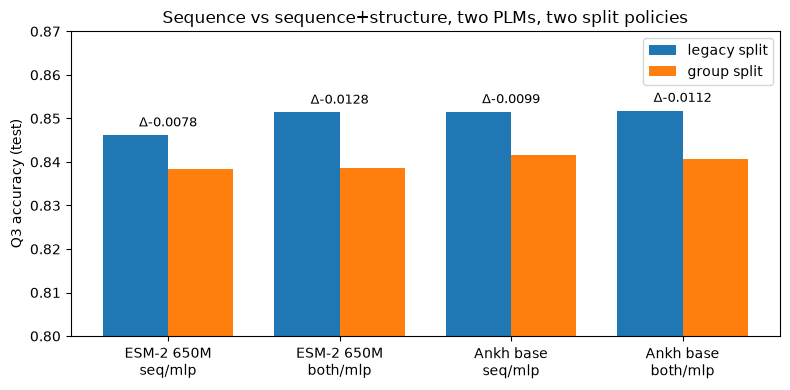

In [13]:
rows: list[tuple[str, str, str]] = [
    ("esm2_t33_650M", "seq", "mlp"),
    ("esm2_t33_650M", "both", "mlp"),
    ("ankh_base", "seq", "mlp"),
    ("ankh_base", "both", "mlp"),
]

labels: list[str] = [f"{LABEL[embed]}\n{features}/{model}" for embed, features, model in rows]

leg_vals: list[float] = [q3(embed, "legacy", features, model) for embed, features, model in rows]

grp_vals: list[float] = [q3(embed, "groups", features, model) for embed, features, model in rows]

x = np.arange(len(rows))
w = 0.38

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    x - w / 2,
    leg_vals,
    w,
    label="legacy split",
)

ax.bar(
    x + w / 2,
    grp_vals,
    w,
    label="group split",
)

for i, (lv, gv) in enumerate(zip(leg_vals, grp_vals, strict=True)):
    ax.text(
        i,
        max(lv, gv) + 0.002,
        f"Δ{gv - lv:+.4f}",
        ha="center",
        fontsize=9,
    )

ax.set_xticks(x, labels)
ax.set_ylim(0.80, 0.87)
ax.set_ylabel("Q3 accuracy (test)")
ax.set_title("Sequence vs sequence+structure, two PLMs, two split policies")
ax.legend()

fig.tight_layout()

### Free Determinism proof

`features=struct` never touches the embedding source 
So the struct rows of the ESM and Ankh tables are **the same computation** and must agree bitwise if the system is truly deterministic.

In [14]:
for split in ("legacy", "groups"):
    a: float = q3(
        "esm2_t33_650M",
        split,
        "struct",
        "gearnet",
    )

    b: float = q3(
        "ankh_base",
        split,
        "struct",
        "gearnet",
    )

    assert a == b, (a, b)

    print(f"struct/gearnet [{split}]: ESM == Ankh == {a:.16f}")

struct/gearnet [legacy]: ESM == Ankh == 0.7076886170085163
struct/gearnet [groups]: ESM == Ankh == 0.6878906898268518


## Caveats

 - **Per-residue accuracy pools correlated residues** (neighbors in one protein are not independent) no binomial CIs; n_test is 75–76 *proteins*. Paired per-protein bootstrap machinery exists (`scripts/per_protein.py` + `notebooks/analysis.py`) and could extend the analysis.
 - **Across-regime difference is unpaired** (different test proteins per split policy); within a table, all rows share identical splits (verified at run time from `splits.json`).
 - **One hyperparameter set** GVP's weak rows might stem from the lack of hyperparameter sweep.
 - **Homology**: pool culled at ≤25% identity (PISCES, independently re-verified: 0.09% of pairs over threshold); group splits add protection

## Extensions, in increasing cost

 1. Per-protein paired bootstrap (code already committed) would yield CIs on every difference.
 2. PLM scale sweep: `--embed esm2_t6_8M / esm2_t30_150M` to assess the return on investment for size.
 3. Additional tasks (like binding site prediction and whatnot)